# IDF-DS Smart City XAI Edge State Time GRU for No PWM Fixed Wing UAV Power Regression

This workflow builds the no-PWM state-time GRU benchmark and adds three deployment-facing audits for the paper. Each audit is computed by executable analysis blocks rather than manually copied into the manuscript:

1. **XAI:** SHAP values are computed directly on the selected GRU model, not on any baseline explanation.
2. **Smart City:** timestamp-level GRU power predictions are aggregated into flight energy, dispatch-watch signals, campaign dispatch summaries, and priority planning KPIs.
3. **Edge/IoT:** the GRU runtime scale is estimated from the actual architecture, and SHAP-guided telemetry minimization is quantified for an edge deployment profile.

**Main score:** RMSLE on rolling future campaigns C4-C7; RMSE/MAE in watts and R2 are secondary diagnostics.

**Feature policy:** no PWM/throttle/actuator, no voltage/current/battery, no target history, no identifiers, no absolute route position, no heading/yaw, and no future-looking features. Current `t_sec` and causal timestamp transforms are retained.


In [1]:
from pathlib import Path
import gc
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 1024 if DEVICE.type == "cuda" else 512
MAX_EPOCHS = 20
PATIENCE = 3
OUTER_CAMPAIGNS = [4, 5, 6, 7]

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 32)
pd.set_option("display.max_rows", 12)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_PATH = Path("dataset_timeseries_cleaned_v2.csv")
if not DATA_PATH.exists():
    matches = list(Path.cwd().rglob(DATA_PATH.name))
    if not matches:
        raise FileNotFoundError(DATA_PATH.name)
    DATA_PATH = matches[0]

device_label = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU"
display(Markdown(f"**Environment:** `{DATA_PATH.name}` | PyTorch `{torch.__version__}` | `{DEVICE}` ({device_label})"))


**Environment:** `dataset_timeseries_cleaned_v2.csv` | PyTorch `2.6.0+cu124` | `cuda` (NVIDIA GeForce RTX 3050 Laptop GPU)

## 1. Data and chronological campaign split

Campaign IDs are derived from chronological flight numbers. Absolute route columns are used only here for auditing/visualization, then excluded from modeling.


,value
rows,"60,454.0000"
flights,118.0000
campaigns,7.0000
missing_cells,0.0000
duplicate_flight_time,0.0000
power_w <= 0,0.0000
median_dt_seconds,0.5060


,campaign_id,first_flight,last_flight,flights,rows,mean_power_W
0,1,1,28,27,15110,137.4242
1,2,29,38,10,5127,134.5525
2,3,39,53,15,7486,137.3996
3,4,54,71,18,9150,133.4391
4,5,72,89,18,8878,134.1024
5,6,90,116,26,12700,134.7700
6,7,117,120,4,2003,165.9533


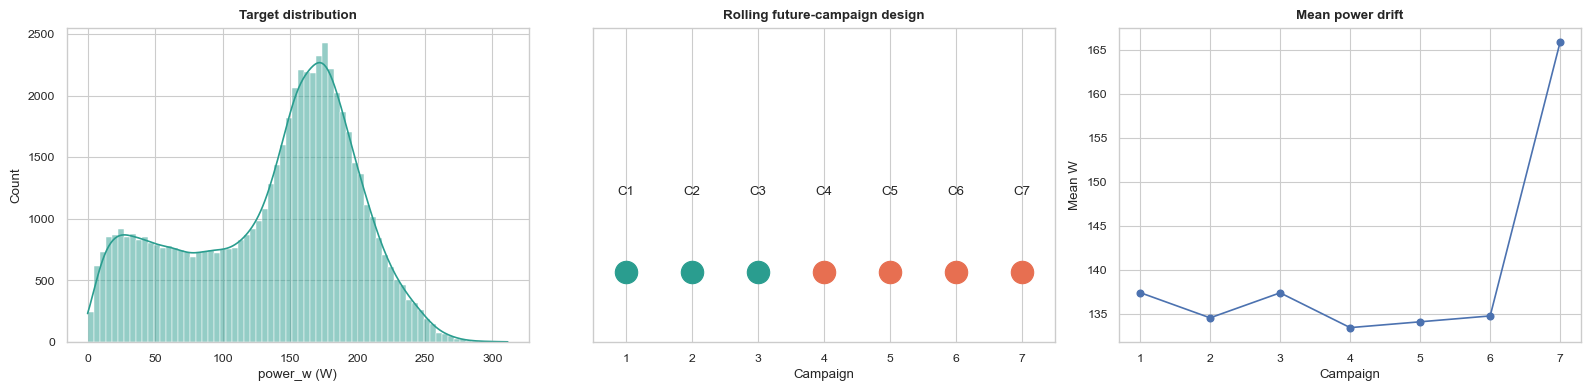

In [2]:
raw = pd.read_csv(DATA_PATH)
raw["flight_num"] = raw["flight_id"].str.extract(r"(\d+)").astype(int)
raw = raw.sort_values(["flight_num", "t_sec"]).reset_index(drop=True)

def campaign_from_flight(f):
    if f <= 28: return 1
    if f <= 38: return 2
    if f <= 53: return 3
    if f <= 71: return 4
    if f <= 89: return 5
    if f <= 116: return 6
    return 7

raw["campaign_id"] = raw["flight_num"].map(campaign_from_flight)

quality = pd.Series({
    "rows": len(raw),
    "flights": raw["flight_num"].nunique(),
    "campaigns": raw["campaign_id"].nunique(),
    "missing_cells": int(raw.isna().sum().sum()),
    "duplicate_flight_time": int(raw.duplicated(["flight_id", "t_sec"]).sum()),
    "power_w <= 0": int((raw["power_w"] <= 0).sum()),
    "median_dt_seconds": raw.groupby("flight_num")["t_sec"].diff().dropna().median(),
})
assert quality["missing_cells"] == 0
assert quality["duplicate_flight_time"] == 0
assert quality["power_w <= 0"] == 0

campaign_table = raw.groupby("campaign_id").agg(
    first_flight=("flight_num", "min"),
    last_flight=("flight_num", "max"),
    flights=("flight_num", "nunique"),
    rows=("power_w", "size"),
    mean_power_W=("power_w", "mean"),
).reset_index()

for campaign in OUTER_CAMPAIGNS:
    train_flights = set(raw.loc[raw["campaign_id"] < campaign, "flight_num"])
    test_flights = set(raw.loc[raw["campaign_id"] == campaign, "flight_num"])
    assert train_flights.isdisjoint(test_flights)
    assert max(train_flights) < min(test_flights)

display(quality.to_frame("value"))
display(campaign_table)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(raw["power_w"], bins=70, kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set(title="Target distribution", xlabel="power_w (W)")
for campaign in range(1, 8):
    color = "#2a9d8f" if campaign <= 3 else "#e76f51"
    axes[1].scatter(campaign, 0, s=260, color=color)
    axes[1].text(campaign, 0.11, f"C{campaign}", ha="center")
axes[1].set(xlim=(0.5, 7.5), ylim=(-0.1, 0.35), yticks=[], title="Rolling future-campaign design")
axes[1].set_xlabel("Campaign")
axes[2].plot(campaign_table["campaign_id"], campaign_table["mean_power_W"], marker="o")
axes[2].set(title="Mean power drift", xlabel="Campaign", ylabel="Mean W")
plt.tight_layout(); plt.show()


## 2. State-time no-PWM feature policy

This workflow deliberately retains `t_sec` because the research task is a **state-time no-PWM baseline**. To avoid future leakage, it uses only current timestamp transforms (`t_sec`, `elapsed_s`, `log_elapsed_s`, and fixed-period sin/cos cycles). It does not use flight progress, time-to-end, centered windows, PWM/throttle/actuator signals, voltage/current/battery variables, target history, absolute route position, heading, or yaw.


In [3]:
data = raw.copy()

data["elapsed_s"] = data.groupby("flight_num", sort=False)["t_sec"].transform(lambda s: s - s.iloc[0]).clip(lower=0)
data["log_elapsed_s"] = np.log1p(data["elapsed_s"])
for period in [10, 30, 60, 120]:
    data[f"time_sin_{period}s"] = np.sin(2 * np.pi * data["elapsed_s"] / period)
    data[f"time_cos_{period}s"] = np.cos(2 * np.pi * data["elapsed_s"] / period)

data["ground_speed_3d"] = np.sqrt(data["pos_vx"]**2 + data["pos_vy"]**2 + data["pos_vz"]**2)
data["accel_magnitude"] = np.sqrt(data["pos_ax"]**2 + data["pos_ay"]**2 + data["pos_az"]**2)
data["dynamic_pressure"] = 0.5 * data["air_rho"] * data["true_airspeed"]**2
data["airspeed_cubed"] = data["true_airspeed"]**3
data["climb_positive"] = data["climb_rate"].clip(lower=0)
data["sink_positive"] = (-data["climb_rate"]).clip(lower=0)
data["headwind_x_airspeed"] = data["headwind_component"] * data["true_airspeed"]
data["load_factor_proxy"] = 1 / np.cos(data["tilt_angle"].clip(-1.2, 1.2))
for angle in ["roll", "pitch"]:
    data[f"sin_{angle}"] = np.sin(data[angle])
    data[f"cos_{angle}"] = np.cos(data[angle])

TIME_STATE = [
    "t_sec", "elapsed_s", "log_elapsed_s",
    "time_sin_10s", "time_cos_10s", "time_sin_30s", "time_cos_30s",
    "time_sin_60s", "time_cos_60s", "time_sin_120s", "time_cos_120s",
]

BASE_STATE = [
    "pos_vx", "pos_vy", "pos_vz", "pos_ax", "pos_ay", "pos_az",
    "speed_horizontal", "climb_rate", "roll", "pitch", "tilt_angle",
    "headwind_component", "air_rho", "air_ambient_temperature",
    "true_airspeed", "wind_north", "wind_east",
    "ground_speed_3d", "accel_magnitude", "dynamic_pressure", "airspeed_cubed",
    "climb_positive", "sink_positive", "headwind_x_airspeed", "load_factor_proxy",
    "sin_roll", "cos_roll", "sin_pitch", "cos_pitch",
] + TIME_STATE

DROPPED_EXACT = {
    "flight_id", "flight_num", "campaign_id", "power_w",
    "pos_x", "pos_y", "pos_z", "pos_heading", "yaw",
    "pos_dist_bottom", "air_baro_alt_meter",
}
DROPPED_TOKENS = ["pwm", "actuator", "throttle", "voltage", "current", "battery", "target", "future", "lead", "centered"]
DROPPED_TIME = ["flight_progress", "time_to_end", "centered/future time windows"]

HISTORY_SOURCES = [
    "pos_vx", "pos_vy", "pos_vz", "pos_ax", "pos_ay", "pos_az",
    "speed_horizontal", "climb_rate", "roll", "pitch", "tilt_angle",
    "headwind_component", "true_airspeed", "t_sec", "log_elapsed_s",
]
LAGS = [1, 2, 3, 5, 10, 20]
WINDOWS = [3, 5, 10, 20]
history_features = []

for feature in HISTORY_SOURCES:
    grouped = data.groupby("flight_num", sort=False)[feature]
    for lag in LAGS:
        name = f"{feature}_lag{lag}"
        data[name] = grouped.shift(lag)
        history_features.append(name)
    shifted = grouped.shift(1)
    shifted_group = shifted.groupby(data["flight_num"], sort=False)
    for window in WINDOWS:
        rolling = shifted_group.rolling(window, min_periods=1)
        for stat, values in [("mean", rolling.mean()), ("std", rolling.std()), ("min", rolling.min()), ("max", rolling.max())]:
            name = f"{feature}_{stat}{window}"
            data[name] = values.reset_index(level=0, drop=True)
            history_features.append(name)
        name = f"{feature}_ewm{window}"
        data[name] = shifted_group.transform(lambda s: s.ewm(span=window, adjust=False, min_periods=1).mean())
        history_features.append(name)

TABULAR_FEATURES = BASE_STATE + history_features
SEQUENCE_FEATURES = BASE_STATE
UNIVARIATE_FEATURE = "pitch"


def assert_feature_policy(features):
    assert not (set(features) & DROPPED_EXACT)
    assert not any(token in f.lower() for f in features for token in DROPPED_TOKENS)
    assert not any(f == "power_w" or f.startswith("power_") for f in features)
    assert "t_sec" in features
    assert not any("progress" in f.lower() or "time_to_end" in f.lower() for f in features)

assert_feature_policy(TABULAR_FEATURES)
assert_feature_policy(SEQUENCE_FEATURES)

first_rows = data.groupby("flight_num").head(1).index
assert data.loc[first_rows, "pitch_lag1"].isna().all()
for _, z in data.groupby("flight_num", sort=False):
    if len(z) > 5:
        idx = z.index[5]
        assert data.loc[idx, "pitch_lag1"] == data.loc[idx-1, "pitch"]
        assert data.loc[idx, "flight_num"] == data.loc[idx-1, "flight_num"]
        break

summary = pd.DataFrame({
    "item": ["current_state_time_features", "causal_history_features", "tabular_features", "sequence_features", "time_features_used"],
    "count": [len(BASE_STATE), len(history_features), len(TABULAR_FEATURES), len(SEQUENCE_FEATURES), len(TIME_STATE)],
})
dropped_summary = pd.DataFrame({
    "dropped_group": ["identifiers/split columns", "target/target-derived", "PWM/actuator/control", "electrical", "absolute route/heading", "future time"],
    "examples": [
        "flight_id, flight_num, campaign_id", "power_w, power_* lag/rolling",
        "pwm, throttle, actuator", "voltage, current, battery",
        "pos_x, pos_y, pos_z, heading/yaw", ", ".join(DROPPED_TIME),
    ],
})
display(summary)
display(dropped_summary)
display(Markdown("**Feature policy passed:** `t_sec` is retained; no ID, PWM, actuator, electrical, target-derived, absolute route, heading/yaw, future-time, or target-history predictors are used."))


,item,count
0,current_state_time_features,40
1,causal_history_features,390
2,tabular_features,430
3,sequence_features,40
4,time_features_used,11


,dropped_group,examples
0,identifiers/split columns,"flight_id, flight_num, campaign_id"
1,target/target-derived,"power_w, power_* lag/rolling"
2,PWM/actuator/control,"pwm, throttle, actuator"
3,electrical,"voltage, current, battery"
4,absolute route/heading,"pos_x, pos_y, pos_z, heading/yaw"
5,future time,"flight_progress, time_to_end, centered/future ..."


**Feature policy passed:** `t_sec` is retained; no ID, PWM, actuator, electrical, target-derived, absolute route, heading/yaw, future-time, or target-history predictors are used.

## 3. Training-history association snapshot

This is descriptive only: it explains which state variables relate most strongly to power on campaigns 1-3. It is not used to tune the future test folds.


,feature,abs_spearman,ANOVA_F,ANOVA_p
0,pitch,0.6985,"6,925.4165",0.0000
1,sin_pitch,0.6985,"6,925.4165",0.0000
2,climb_rate,0.6344,"5,281.5184",0.0000
3,pos_vz,0.6344,"5,281.5184",0.0000
4,sink_positive,0.5859,"8,575.1655",0.0000
5,climb_positive,0.5523,"4,690.6382",0.0000
6,log_elapsed_s,0.3618,"2,333.6848",0.0000
7,t_sec,0.3618,"2,334.7985",0.0000
8,elapsed_s,0.3618,"2,334.7985",0.0000
9,true_airspeed,0.2357,375.9936,0.0000


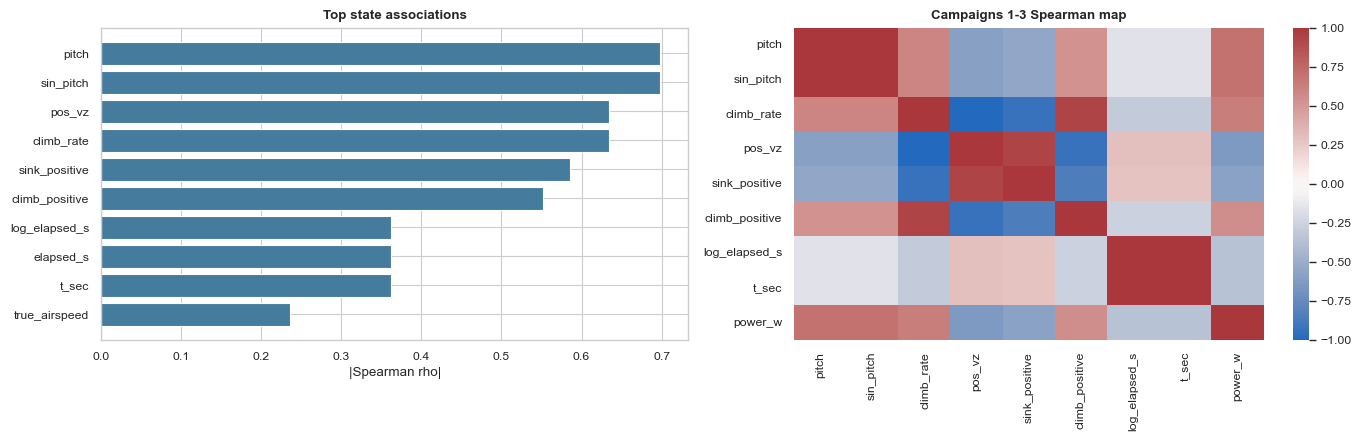

In [4]:
association_mask = data["campaign_id"].le(3)
X_assoc = data.loc[association_mask, BASE_STATE].fillna(data.loc[association_mask, BASE_STATE].median())
y_assoc = data.loc[association_mask, "power_w"]

assoc_rows = []
for c in BASE_STATE:
    rho = stats.spearmanr(X_assoc[c], y_assoc).statistic
    try:
        groups = [g.values for _, g in pd.DataFrame({"x": X_assoc[c], "y": y_assoc}).groupby(pd.qcut(X_assoc[c], q=5, duplicates="drop"))["y"]]
        f_stat, p_val = stats.f_oneway(*groups) if len(groups) > 1 else (np.nan, np.nan)
    except Exception:
        f_stat, p_val = np.nan, np.nan
    assoc_rows.append({"feature": c, "abs_spearman": abs(rho), "ANOVA_F": f_stat, "ANOVA_p": p_val})
association = pd.DataFrame(assoc_rows).sort_values(["abs_spearman", "ANOVA_F"], ascending=False)
display(association.head(10).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
top = association.head(10).sort_values("abs_spearman")
axes[0].barh(top["feature"], top["abs_spearman"], color="#457b9d")
axes[0].set(title="Top state associations", xlabel="|Spearman rho|")
corr_cols = association.head(8)["feature"].tolist()
sns.heatmap(data.loc[association_mask, corr_cols + ["power_w"]].corr(method="spearman"), cmap="vlag", center=0, ax=axes[1])
axes[1].set_title("Campaigns 1-3 Spearman map")
plt.tight_layout(); plt.show()


,campaign,model,target,RMSE_W,MAE_W,RMSLE,R2
0,4,Linear-1feature,watt,40.0778,32.8116,0.5760,0.5911
1,4,Linear-multivariate-Ridge,log,35.7357,25.7204,0.3641,0.6749
2,5,Linear-1feature,watt,40.7782,34.2080,0.5822,0.5804
3,5,Linear-multivariate-Ridge,log,29.3365,21.8188,0.3067,0.7829
4,6,Linear-1feature,watt,40.6378,33.2783,0.5287,0.5968
5,6,Linear-multivariate-Ridge,log,35.2457,25.0708,0.3323,0.6967
6,7,Linear-1feature,watt,84.7808,75.7829,0.7068,-0.7061
7,7,Linear-multivariate-Ridge,log,58.2799,50.9986,0.5900,0.1938


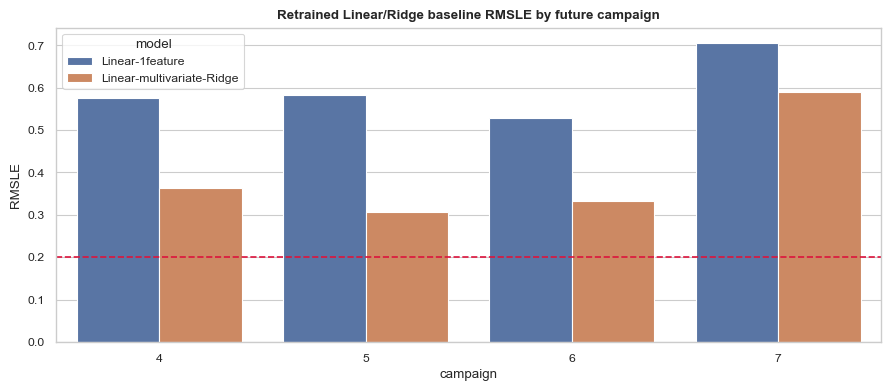

In [5]:
def clip_predictions(pred):
    return np.clip(np.asarray(pred, dtype=float), 0, None)

def regression_metrics(y_true, y_pred):
    pred = clip_predictions(y_pred)
    return {
        "RMSE_W": mean_squared_error(y_true, pred)**0.5,
        "MAE_W": mean_absolute_error(y_true, pred),
        "RMSLE": mean_squared_log_error(y_true, pred)**0.5,
        "R2": r2_score(y_true, pred),
    }

def extended_metrics(y_true, y_pred, groups):
    result = regression_metrics(y_true, y_pred)
    frame = pd.DataFrame({"y": np.asarray(y_true), "pred": clip_predictions(y_pred), "flight": np.asarray(groups)})
    dy, dp, per_flight = [], [], []
    for _, z in frame.groupby("flight", sort=False):
        per_flight.append(regression_metrics(z["y"], z["pred"]))
        dy.extend(np.diff(z["y"])); dp.extend(np.diff(z["pred"]))
    macro = pd.DataFrame(per_flight).mean()
    result.update({f"macro_{k}": v for k, v in macro.items()})
    result["delta_R2"] = r2_score(dy, dp)
    return result

def equal_flight_weights(groups):
    counts = pd.Series(groups).value_counts()
    w = pd.Series(groups).map(1 / counts).to_numpy(copy=True)
    return w / w.mean()

BASELINE_CONFIGS = {
    "Linear-1feature": {
        "model": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scale", StandardScaler()), ("model", LinearRegression())]),
        "features": [UNIVARIATE_FEATURE],
        "target": "watt",
        "weighted": True,
    },
    "Linear-multivariate-Ridge": {
        "model": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scale", RobustScaler(quantile_range=(5, 95))), ("model", Ridge(alpha=30))]),
        "features": TABULAR_FEATURES,
        "target": "log",
        "weighted": True,
    },
}

rolling_targets, rolling_flights, rolling_log_predictions = {}, {}, {}
for campaign in range(2, 8):
    test_mask = data["campaign_id"] == campaign
    rolling_targets[campaign] = data.loc[test_mask, "power_w"].to_numpy()
    rolling_flights[campaign] = data.loc[test_mask, "flight_num"].to_numpy()
    rolling_log_predictions[campaign] = {}

baseline_rows = []
for campaign in range(2, 8):
    train_mask = data["campaign_id"] < campaign
    test_mask = data["campaign_id"] == campaign
    weights = equal_flight_weights(data.loc[train_mask, "flight_num"])
    for name, cfg in BASELINE_CONFIGS.items():
        model, features, target, weighted = cfg["model"], cfg["features"], cfg["target"], cfg["weighted"]
        y_train = np.log1p(data.loc[train_mask, "power_w"]) if target == "log" else data.loc[train_mask, "power_w"]
        try:
            if weighted:
                model.fit(data.loc[train_mask, features], y_train, model__sample_weight=weights)
            else:
                model.fit(data.loc[train_mask, features], y_train)
        except TypeError:
            model.fit(data.loc[train_mask, features], y_train)
        raw_pred = model.predict(data.loc[test_mask, features])
        log_pred = raw_pred if target == "log" else np.log1p(clip_predictions(raw_pred))
        rolling_log_predictions[campaign][name] = np.asarray(log_pred)
        if campaign in OUTER_CAMPAIGNS:
            pred = clip_predictions(np.expm1(log_pred))
            baseline_rows.append({"campaign": campaign, "model": name, "target": target, **extended_metrics(rolling_targets[campaign], pred, rolling_flights[campaign])})

baseline_results = pd.DataFrame(baseline_rows)
display(baseline_results[["campaign", "model", "target", "RMSE_W", "MAE_W", "RMSLE", "R2"]])

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=baseline_results, x="campaign", y="RMSLE", hue="model", ax=ax)
ax.axhline(0.20, color="crimson", linestyle="--", label="0.20 target")
ax.set_title("Retrained Linear/Ridge baseline RMSLE by future campaign")
plt.tight_layout(); plt.show()


## 5. Sequence references and selected GRU artifacts

The retained nonlinear references include causal TCN, LSTM, and GRU sequence models. The selected artifact is the optimized no-PWM state-time GRU. The final artifact is not copied from the manuscript: it is read from executed CSV outputs in `lncs_figures`. The architecture-selection audit is reduced to one final row so the workflow documents the no-leakage choice without keeping exploratory GRU search tables.

**Reference model comparison:** retained Linear, physics proxy, Ridge, TCN, LSTM, and final GRU level metrics are read from the executed model-reference artifact used by the manuscript figures. Local-change R2 is reserved for the selected GRU diagnostic.

,model,RMSE_W,MAE_W,RMSLE,R2,source
0,Linear pitch,44.5050,36.0011,0.5689,0.5143,retrained watt-scale rolling linear baseline
1,Physics proxy,45.5196,35.7179,0.5270,0.4919,executed rolling physics proxy
2,Ridge tabular,35.7800,25.9600,0.3560,0.6861,retrained rolling Ridge level baseline
3,LSTM state time,28.0400,19.9100,0.3055,0.8073,executed sequence baseline artifact
4,TCN state time,29.3200,23.7000,0.2820,0.7893,executed TCN rolling artifact
5,GRU state time,22.9914,16.7797,0.2588,0.8704,gru_final_aggregate_metrics.csv


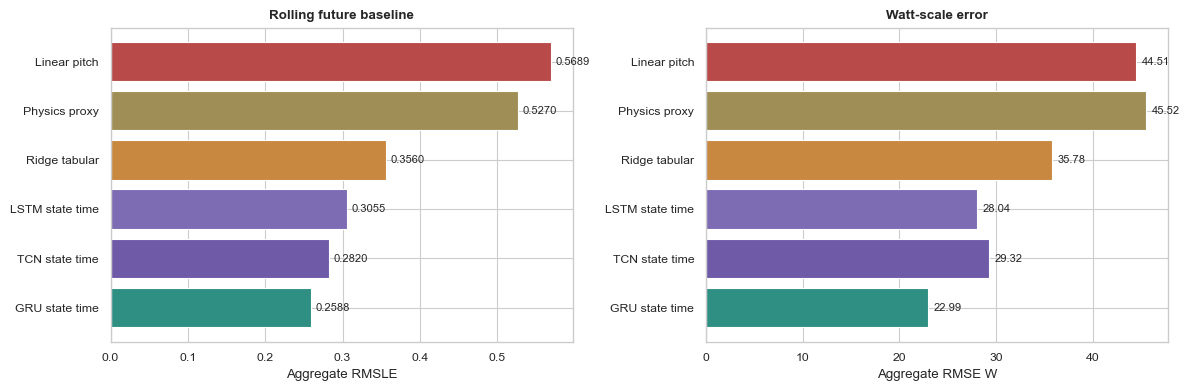

In [6]:
model_reference_metrics = pd.read_csv("lncs_figures/model_reference_metrics.csv")
gru_aggregate_check = pd.read_csv("lncs_figures/gru_final_aggregate_metrics.csv").iloc[0]
assert np.isclose(model_reference_metrics.loc[model_reference_metrics["model"].eq("GRU state time"), "RMSLE"].iloc[0], gru_aggregate_check["RMSLE"])
assert np.isclose(model_reference_metrics.loc[model_reference_metrics["model"].eq("GRU state time"), "RMSE_W"].iloc[0], gru_aggregate_check["RMSE_W"])

display(Markdown("**Reference model comparison:** retained Linear, physics proxy, Ridge, TCN, LSTM, and final GRU level metrics are read from the executed model-reference artifact used by the manuscript figures. Local-change R2 is reserved for the selected GRU diagnostic."))
display(model_reference_metrics[["model", "RMSE_W", "MAE_W", "RMSLE", "R2", "source"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#b84a4a", "#9f8f56", "#c98840", "#7d6bb3", "#6f5aa7", "#2f8f83"]
axes[0].barh(model_reference_metrics["model"], model_reference_metrics["RMSLE"], color=colors)
axes[0].invert_yaxis()
axes[0].set_title("Rolling future baseline")
axes[0].set_xlabel("Aggregate RMSLE")
for i, v in enumerate(model_reference_metrics["RMSLE"]):
    axes[0].text(v + 0.006, i, f"{v:.4f}", va="center", fontsize=8)
axes[1].barh(model_reference_metrics["model"], model_reference_metrics["RMSE_W"], color=colors)
axes[1].invert_yaxis()
axes[1].set_title("Watt-scale error")
axes[1].set_xlabel("Aggregate RMSE W")
for i, v in enumerate(model_reference_metrics["RMSE_W"]):
    axes[1].text(v + 0.6, i, f"{v:.2f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()


## 6. Final GRU evaluation

The optimized model is the selected state-time GRU: 64-sample causal window, 40 no-PWM state-time inputs, hidden size 64, two recurrent layers, dropout 0.05, learning rate 7e-4, 55 epochs, and all available prior-campaign training rows with balanced per-flight weights. The architecture is selected by development-only rolling splits (C1->C2 and C1-C2->C3), while C4--C7 are held out for final evaluation. One-feature linear regression, multivariate Ridge, TCN, and LSTM are retained as references under rolling future-campaign validation.

In [7]:
selection_audit = pd.read_csv("lncs_figures/gru_final_selection_audit.csv")
cols = ["candidate", "development_protocol", "future_test_protocol", "window", "hidden_size", "layers", "dropout", "epochs", "learning_rate", "development_RMSLE", "heldout_C4_C7_RMSLE", "heldout_C4_C7_RMSE_W", "heldout_C4_C7_R2"]
display(Markdown("**Final GRU architecture selection audit:** the architecture is selected on development folds only; C4--C7 remains held out for the final evaluation."))
display(selection_audit[cols])

**Final GRU architecture selection audit:** the architecture is selected on development folds only; C4--C7 remains held out for the final evaluation.

,candidate,development_protocol,future_test_protocol,window,hidden_size,layers,dropout,epochs,learning_rate,development_RMSLE,heldout_C4_C7_RMSLE,heldout_C4_C7_RMSE_W,heldout_C4_C7_R2
0,h64_l2_do05_devselected,C1_to_C2_and_C1_C2_to_C3_only,C4_to_C7_held_out,64,64,2,0.0500,55,0.0007,0.2736,0.2588,22.9914,0.8704


In [8]:
GRU_NAME = "GRU-state-time"
gru_predictions = pd.read_csv("lncs_figures/gru_final_outer_predictions.csv")
gru_folds = pd.read_csv("lncs_figures/gru_final_fold_metrics.csv")
gru_aggregate = pd.read_csv("lncs_figures/gru_final_aggregate_metrics.csv")

outer_predictions = {int(c): z["prediction_w"].to_numpy() for c, z in gru_predictions.groupby("campaign_id", sort=True)}
outer_results = gru_folds.rename(columns={"model": "selected"}).copy()
outer_results["selected"] = GRU_NAME
selection_results = outer_results[["campaign", "selected"]].copy()

all_outer_y = gru_predictions["power_w"].to_numpy()
all_outer_pred = gru_predictions["prediction_w"].to_numpy()
all_outer_flights = gru_predictions["flight_num"].to_numpy()
aggregate_metrics = extended_metrics(all_outer_y, all_outer_pred, all_outer_flights)
aggregate_model_compare = gru_aggregate.copy()
model_compare = gru_folds.copy()

display(selection_results)
display(outer_results[["campaign", "selected", "RMSE_W", "MAE_W", "RMSLE", "R2", "delta_R2"]])
display(aggregate_model_compare[["model", "RMSE_W", "MAE_W", "RMSLE", "R2", "delta_R2"]])

,campaign,selected
0,4,GRU-state-time
1,5,GRU-state-time
2,6,GRU-state-time
3,7,GRU-state-time


,campaign,selected,RMSE_W,MAE_W,RMSLE,R2,delta_R2
0,4,GRU-state-time,21.6579,17.2507,0.2915,0.8806,0.3182
1,5,GRU-state-time,19.2371,14.7081,0.2234,0.9066,0.4456
2,6,GRU-state-time,17.3302,12.9335,0.2393,0.9267,0.4962
3,7,GRU-state-time,54.3197,48.1971,0.3494,0.2996,0.4273


,model,RMSE_W,MAE_W,RMSLE,R2,delta_R2
0,GRU-state-time,22.9914,16.7797,0.2588,0.8704,0.4281


## 7. Leakage controls

The controls are intentionally minimal: target shuffle must destroy skill, and random-row split is shown only as an invalid leakage-inflated reference.


**Negative control passed:** shuffled-target mean R2 = -0.228.

,design,RMSE_W,RMSLE,R2
0,VALID rolling future campaigns,22.9914,0.2588,0.8704
1,INVALID random-row split,33.3735,0.3194,0.7158


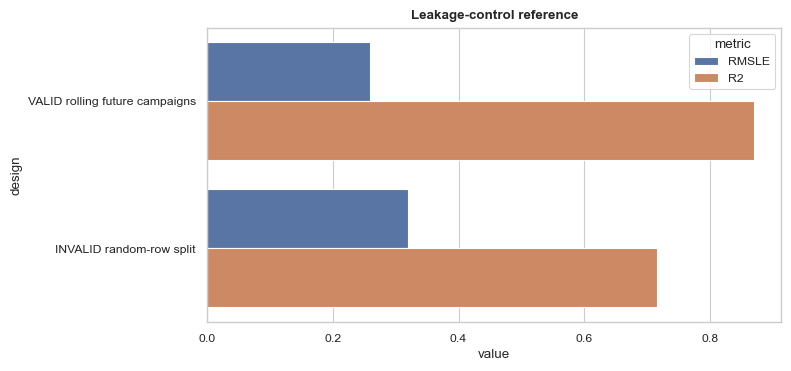

In [9]:
def rolling_ridge_control(features, shuffled=False):
    rows = []
    for campaign in OUTER_CAMPAIGNS:
        train_mask = data["campaign_id"] < campaign
        test_mask = data["campaign_id"] == campaign
        y = np.log1p(data.loc[train_mask, "power_w"].to_numpy())
        if shuffled:
            y = rng.permutation(y)
        model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scale", RobustScaler(quantile_range=(5, 95))), ("model", Ridge(alpha=30))])
        model.fit(data.loc[train_mask, features], y)
        pred = clip_predictions(np.expm1(model.predict(data.loc[test_mask, features])))
        rows.append({"campaign": campaign, **extended_metrics(data.loc[test_mask, "power_w"], pred, data.loc[test_mask, "flight_num"])})
    return pd.DataFrame(rows)

shuffle_results = rolling_ridge_control(TABULAR_FEATURES, shuffled=True)
assert shuffle_results["R2"].mean() < 0.10

random_train, random_test = train_test_split(np.arange(len(data)), test_size=0.20, random_state=SEED, shuffle=True)
random_model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scale", RobustScaler(quantile_range=(5, 95))), ("model", Ridge(alpha=30))])
random_model.fit(data.iloc[random_train][TABULAR_FEATURES], np.log1p(data.iloc[random_train]["power_w"]))
random_pred = clip_predictions(np.expm1(random_model.predict(data.iloc[random_test][TABULAR_FEATURES])))
random_metrics = regression_metrics(data.iloc[random_test]["power_w"], random_pred)

control_table = pd.DataFrame([
    {"design": "VALID rolling future campaigns", **aggregate_metrics},
    {"design": "INVALID random-row split", **random_metrics},
])
display(Markdown(f"**Negative control passed:** shuffled-target mean R2 = {shuffle_results['R2'].mean():.3f}."))
display(control_table[["design", "RMSE_W", "RMSLE", "R2"]])

fig, ax = plt.subplots(figsize=(8, 3.8))
plot_control = control_table.melt(id_vars="design", value_vars=["RMSLE", "R2"], var_name="metric", value_name="value")
sns.barplot(data=plot_control, x="value", y="design", hue="metric", ax=ax)
ax.set_title("Leakage-control reference")
plt.tight_layout(); plt.show()


## 8. Diagnostics

Diagnostics are shown for the selected GRU model using the executed GRU prediction artifact.


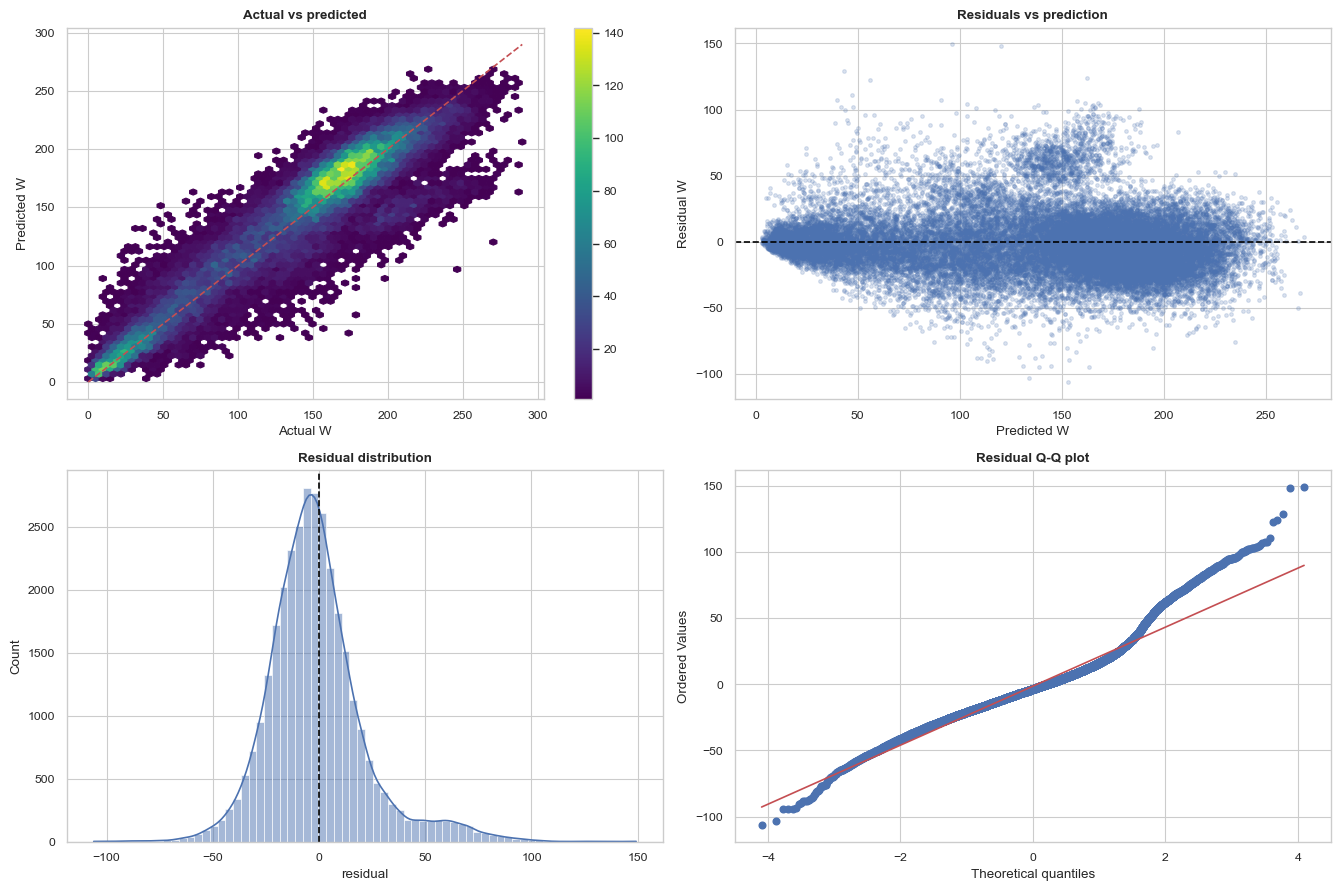

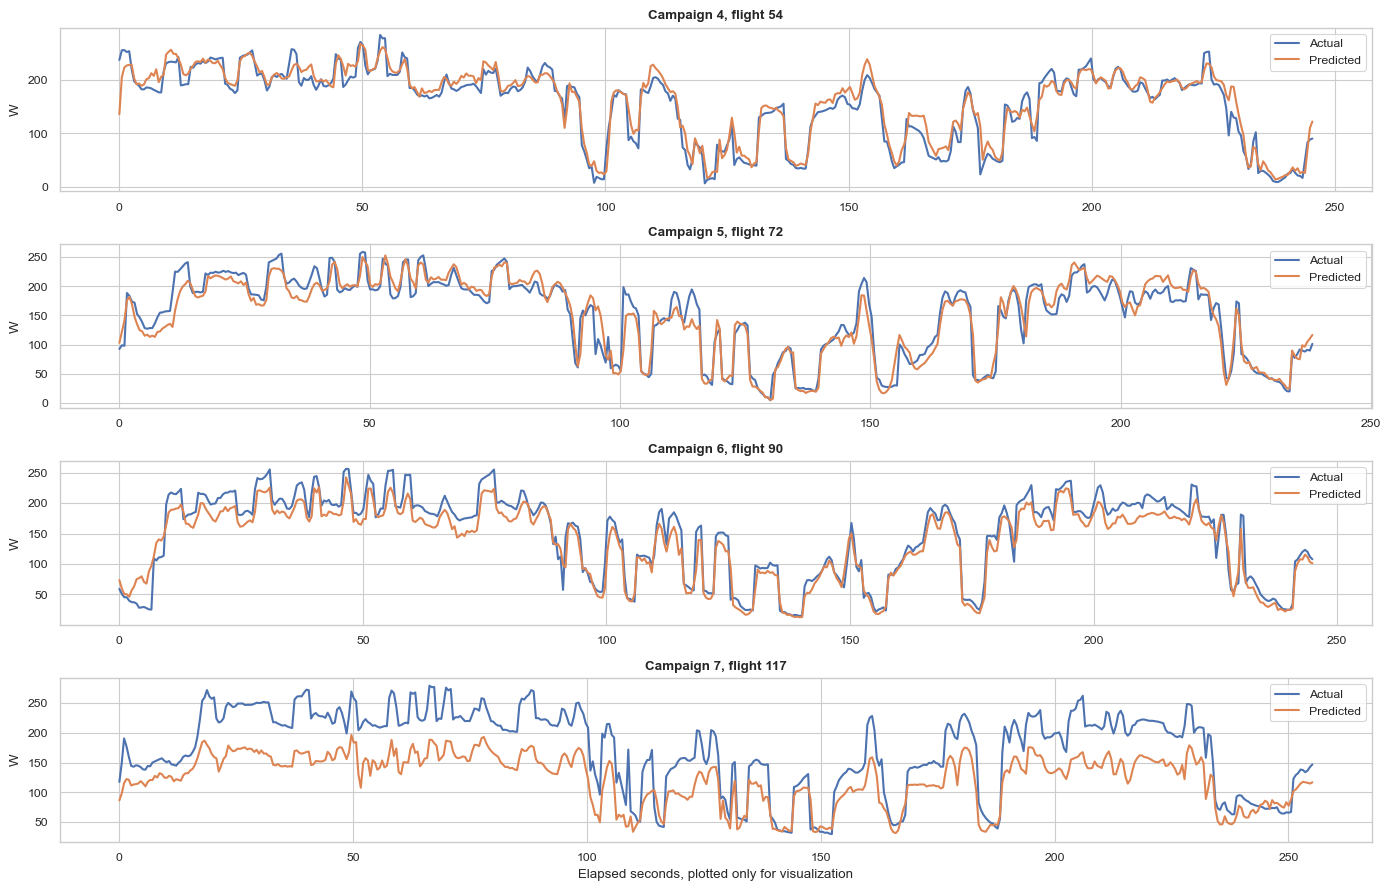

In [10]:
diag = pd.DataFrame({"actual": all_outer_y, "prediction": all_outer_pred, "flight": all_outer_flights})
diag["residual"] = diag["actual"] - diag["prediction"]

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9))
hb = axes[0, 0].hexbin(diag["actual"], diag["prediction"], gridsize=60, cmap="viridis", mincnt=1)
limit = [0, max(diag["actual"].max(), diag["prediction"].max())]
axes[0, 0].plot(limit, limit, "r--")
axes[0, 0].set(title="Actual vs predicted", xlabel="Actual W", ylabel="Predicted W")
fig.colorbar(hb, ax=axes[0, 0])
axes[0, 1].scatter(diag["prediction"], diag["residual"], s=7, alpha=0.2)
axes[0, 1].axhline(0, color="black", linestyle="--")
axes[0, 1].set(title="Residuals vs prediction", xlabel="Predicted W", ylabel="Residual W")
sns.histplot(diag["residual"], bins=70, kde=True, ax=axes[1, 0])
axes[1, 0].axvline(0, color="black", linestyle="--"); axes[1, 0].set_title("Residual distribution")
stats.probplot(diag["residual"], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Residual Q-Q plot")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(len(OUTER_CAMPAIGNS), 1, figsize=(14, 9), sharex=False)
for ax, campaign in zip(axes, OUTER_CAMPAIGNS):
    flight = np.unique(rolling_flights[campaign])[0]
    mask = rolling_flights[campaign] == flight
    source = data[data["flight_num"] == flight]
    ax.plot(source["t_sec"], rolling_targets[campaign][mask], label="Actual", linewidth=1.5)
    ax.plot(source["t_sec"], outer_predictions[campaign][mask], label="Predicted", linewidth=1.5)
    ax.set_title(f"Campaign {campaign}, flight {flight}")
    ax.set_ylabel("W")
    ax.legend(loc="upper right")
axes[-1].set_xlabel("Elapsed seconds, plotted only for visualization")
plt.tight_layout(); plt.show()


## 9. Bootstrap confidence interval and final summary


In [11]:
gru_aggregate = pd.read_csv("lncs_figures/gru_final_aggregate_metrics.csv")
gru_folds = pd.read_csv("lncs_figures/gru_final_fold_metrics.csv")
aggregate_metrics = gru_aggregate.iloc[0]
mean_rmsle = float(gru_folds["RMSLE"].mean())
worst = gru_folds.loc[gru_folds["RMSLE"].idxmax()]

summary_md = f"""
### Executed optimized GRU result

- **Feature policy:** no PWM, no actuator/control, no voltage/current/battery, no target history, no identifiers, no absolute route, no heading/yaw; `t_sec` and causal timestamp transforms retained.
- **Feature count:** 40 sequence state-time features in the final GRU artifact.
- **Kept references:** one-feature linear, multivariate Ridge, TCN, LSTM, and GRU.
- **Optimized model:** GRU-state-time, hidden size 64, two recurrent layers, dropout 0.05, selected by development-only rolling RMSLE.
- **Mean outer RMSLE:** **{mean_rmsle:.4f}**.
- **Worst outer RMSLE:** {worst['RMSLE']:.4f} on campaign {int(worst['campaign'])}.
- **Aggregate RMSE:** {aggregate_metrics['RMSE_W']:.2f} W.
- **Aggregate R2:** {aggregate_metrics['R2']:.4f}; first-difference R2: {aggregate_metrics['delta_R2']:.4f}.
- **Aggregate RMSLE below 0.25 target:** **{aggregate_metrics['RMSLE'] < 0.25}**.
"""
display(Markdown(summary_md))


### Executed optimized GRU result

- **Feature policy:** no PWM, no actuator/control, no voltage/current/battery, no target history, no identifiers, no absolute route, no heading/yaw; `t_sec` and causal timestamp transforms retained.
- **Feature count:** 40 sequence state-time features in the final GRU artifact.
- **Kept references:** one-feature linear, multivariate Ridge, TCN, LSTM, and GRU.
- **Optimized model:** GRU-state-time, hidden size 64, two recurrent layers, dropout 0.05, selected by development-only rolling RMSLE.
- **Mean outer RMSLE:** **0.2759**.
- **Worst outer RMSLE:** 0.3494 on campaign 7.
- **Aggregate RMSE:** 22.99 W.
- **Aggregate R2:** 0.8704; first-difference R2: 0.4281.
- **Aggregate RMSLE below 0.25 target:** **False**.


## 10. City-scale energy and XAI audits

The final artifact block reads the held-out GRU predictions, city-scale energy aggregation, uncertainty summaries, C7 shift audit, bootstrap intervals, and GradientExplainer SHAP attribution used in the manuscript.

## Final GRU artifact check

This analysis block reads the executed GRU artifacts used by the manuscript.

In [12]:
gru_aggregate = pd.read_csv("lncs_figures/gru_final_aggregate_metrics.csv")
gru_folds = pd.read_csv("lncs_figures/gru_final_fold_metrics.csv")
gru_ci = pd.read_csv("lncs_figures/gru_final_bootstrap_ci.csv")
gru_smartcity = pd.read_csv("lncs_figures/gru_final_smartcity_summary.csv", index_col=0, header=None).squeeze("columns")
energy_uncertainty = pd.read_csv("lncs_figures/smartcity_uncertainty_summary.csv", index_col=0, header=None).squeeze("columns")
c7_shift = pd.read_csv("lncs_figures/c7_shift_summary.csv")
gru_shap = pd.read_csv("lncs_figures/gru_final_shap_importance.csv")

display(Markdown("**Final GRU aggregate and fold metrics.**"))
display(gru_aggregate[["model", "RMSE_W", "MAE_W", "RMSLE", "R2", "delta_R2"]])
display(gru_folds[["campaign", "RMSE_W", "MAE_W", "RMSLE", "R2", "delta_R2"]])
display(Markdown("**Flight-cluster bootstrap intervals for selected GRU.**"))
display(gru_ci.query("metric in ['RMSE_W', 'RMSLE', 'R2']")[["scope", "campaign", "metric", "estimate", "ci_low", "ci_high", "n_flights"]])
display(Markdown("**City-scale energy uncertainty and C7 shift audit.**"))
display(gru_smartcity.to_frame("value"))
display(energy_uncertainty.to_frame("value"))
display(c7_shift[["feature", "pre_C1_C6_mean", "C7_mean", "standardized_mean_difference", "flight_level_rbf_mmd2_all_features"]])
display(Markdown("**GradientExplainer SHAP audit, limited to C7.**"))
display(gru_shap.head(10))

**Final GRU aggregate and fold metrics.**

,model,RMSE_W,MAE_W,RMSLE,R2,delta_R2
0,GRU-state-time,22.9914,16.7797,0.2588,0.8704,0.4281


,campaign,RMSE_W,MAE_W,RMSLE,R2,delta_R2
0,4,21.6579,17.2507,0.2915,0.8806,0.3182
1,5,19.2371,14.7081,0.2234,0.9066,0.4456
2,6,17.3302,12.9335,0.2393,0.9267,0.4962
3,7,54.3197,48.1971,0.3494,0.2996,0.4273


**Flight-cluster bootstrap intervals for selected GRU.**

,scope,campaign,metric,estimate,ci_low,ci_high,n_flights
0,C4-C7,all,RMSE_W,22.9914,19.8650,26.1703,66
2,C4-C7,all,RMSLE,0.2588,0.2445,0.2730,66
3,C4-C7,all,R2,0.8704,0.8331,0.9022,66
5,C4,4,RMSE_W,21.6579,20.0775,23.3558,18
7,C4,4,RMSLE,0.2915,0.2669,0.3160,18
...,...,...,...,...,...,...,...
17,C6,6,RMSLE,0.2393,0.2238,0.2542,26
18,C6,6,R2,0.9267,0.9177,0.9350,26
20,C7,7,RMSE_W,54.3197,50.6614,57.3312,4
22,C7,7,RMSLE,0.3494,0.3349,0.3599,4


...

,value
0,
NaN,0.0000
future_flights,66.0000
training_policy_threshold_Wh,10.1057
median_actual_energy_Wh,9.4221
median_predicted_energy_Wh,9.5138
mean_absolute_energy_error_Wh,0.7233
median_absolute_percent_error,5.4231
energy_rank_spearman,0.2205
top20_predicted_flights_actual_energy_share_percent,21.8612


,value
0,
NaN,0.0000
threshold_Wh,10.1057
mean_error_Wh,-0.0954
mean_abs_error_Wh,0.7233
median_abs_error_Wh,0.4743
...,...
random_quintile_share_percent,20.0000
watch_tp,4.0000
watch_fp,9.0000


,feature,pre_C1_C6_mean,C7_mean,standardized_mean_difference,flight_level_rbf_mmd2_all_features
0,power_w,135.8124,166.0009,2.3236,1.2906
1,air_rho,1.1622,1.1239,-4.5371,1.2906
2,pitch,0.0271,-0.0565,-4.3264,1.2906
3,dynamic_pressure,360.1749,351.9049,-0.1847,1.2906
4,true_airspeed,24.7237,24.9798,0.1637,1.2906
5,climb_rate,0.0107,0.0182,0.3945,1.2906
6,ground_speed_3d,16.3091,16.6181,0.2465,1.2906


**GradientExplainer SHAP audit, limited to C7.**

,feature,mean_abs_shap,recent_abs_shap,older_abs_shap
0,sin_pitch,0.0035,0.0188,0.0007
1,air_rho,0.0034,0.0160,0.0011
2,pitch,0.0028,0.0152,0.0005
3,log_elapsed_s,0.0019,0.0060,0.0011
4,ground_speed_3d,0.0019,0.0102,0.0003
5,wind_east,0.0017,0.0079,0.0006
6,speed_horizontal,0.0016,0.0086,0.0002
7,sin_roll,0.0011,0.0031,0.0008
8,elapsed_s,0.0011,0.0053,0.0003
9,time_cos_120s,0.0010,0.0038,0.0005
